# 02 — Baseline Models

**Goal:** establish how well standard classifiers predict `machine_failure` from the **raw sensor
readings only**. This is the "black box" reference point that later notebooks try to explain (M3)
and beat with domain knowledge (M4).

All evaluation logic lives in `src/pdm/evaluate.py`, and all model definitions live in
`src/pdm/models.py`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve

from pdm.config import FIGURES_DIR, PROJECT_ROOT
from pdm.data import FAILURE_MODES, FEATURES, NUMERIC_FEATURES, TARGET, load_data
from pdm.evaluate import compare_models, make_cv
from pdm.models import baseline_models

sns.set_theme(style="whitegrid", context="notebook")
REPORTS_DIR = PROJECT_ROOT / "reports"
MODEL_COLORS = {
    "HistGradientBoosting": "#c44e52",
    "RandomForest (balanced)": "#4c72b0",
    "LogReg (balanced)": "#8d99ae",
}


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"02_{name}.png", dpi=150, bbox_inches="tight")


def show_results(results):
    cols = ["pr_auc", "roc_auc", "threshold", "precision", "recall", "f1", "tp", "fp", "fn"]
    return results[cols].style.format(
        {c: "{:.3f}" for c in cols[:6]} | {c: "{:.0f}" for c in cols[6:]}
    )

In [2]:
df = load_data()
X, y = df[FEATURES], df[TARGET]
print(f"Features: {FEATURES}")
print(f"Rows: {len(X):,} | Failures: {y.sum()} ({y.mean():.1%})")

Features: ['type', 'air_temp_k', 'process_temp_k', 'rpm', 'torque_nm', 'tool_wear_min']
Rows: 10,000 | Failures: 339 (3.4%)


## 1. Evaluation protocol

- **Stratified 5-fold cross-validation** with fixed splits, so every fold has about 3.4% failures
  and every model sees exactly the same folds.
- **Out-of-fold (OOF) predictions:** each row is scored by a model that did not see it during
  training. This gives one honest probability per row for the whole dataset.
- **PR-AUC (average precision)** is the main metric. It focuses on the rare failure class.
  A random classifier scores about 0.034 (the failure rate), and a perfect one scores 1.0.
- **ROC-AUC** is reported for completeness, but it looks optimistic on imbalanced data because the
  many easy negatives dominate it.
- **F1 at the best threshold:** the threshold that maximises F1 on the OOF predictions.
  Because the threshold is tuned on the same predictions it is scored on, this F1 is slightly
  optimistic. It is fine for comparing models, and M5 replaces it with a cost-based choice.

**Bug fix from the original notebook:** `precision_recall_curve` returns one more precision/recall
value than thresholds, and `precision[i]` belongs to `thresholds[i]`. The original code used
`thresholds[best_idx - 1]`, which picks the neighbouring threshold. `best_f1_threshold()` uses the
correct index and is covered by unit tests.

## 2. Model candidates on raw features

| Model | Why it is included |
|---|---|
| Logistic regression (class-weighted) | Linear reference: shows how much non-linearity matters |
| Random forest (class-weighted) | Robust non-linear ensemble |
| Histogram gradient boosting | Strong default for tabular data |

All models share the same preprocessing: numeric features are standardised and `type` is one-hot
encoded. Scaling only matters for logistic regression, but a shared pipeline keeps the comparison
simple.

In [3]:
results, probas = compare_models(baseline_models(), X, y, cv=make_cv())
show_results(results)

,pr_auc,roc_auc,threshold,precision,recall,f1,tp,fp,fn
model,,,,,,,,,
HistGradientBoosting,0.835,0.978,0.288,0.801,0.758,0.779,257,64,82
RandomForest (balanced),0.766,0.971,0.517,0.776,0.676,0.722,229,66,110
LogReg (balanced),0.424,0.900,0.861,0.407,0.496,0.447,168,245,171


- **Gradient boosting is the best baseline** with PR-AUC ≈ 0.84 and F1 ≈ 0.78.
  It catches about three out of four failures, and about four out of five alarms are real.
- **Random forest** is clearly behind on PR-AUC.
- **Logistic regression** reaches only PR-AUC ≈ 0.42. With a linear decision boundary it cannot
  represent failure regions such as "high torque *and* low speed", which confirms the EDA finding
  that failures depend on non-linear interactions.
- All models have a high ROC-AUC (0.90–0.98), even logistic regression. This shows why ROC-AUC alone
  would be misleading here.

## 3. Precision-recall curves

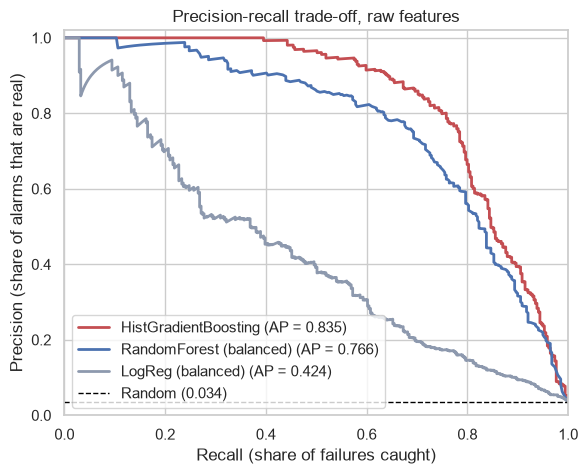

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name in results.index:
    precision, recall, _ = precision_recall_curve(y, probas[name])
    label = f"{name} (AP = {results.loc[name, 'pr_auc']:.3f})"
    ax.plot(recall, precision, color=MODEL_COLORS[name], lw=2, label=label)
ax.axhline(y.mean(), color="black", ls="--", lw=1, label=f"Random ({y.mean():.3f})")
ax.set_xlabel("Recall (share of failures caught)")
ax.set_ylabel("Precision (share of alarms that are real)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title("Precision-recall trade-off, raw features")
ax.legend(loc="lower left")
save(fig, "pr_curves")
plt.show()

Gradient boosting keeps precision above 90% up to a recall of about 60%. The random forest loses
precision much earlier. Beyond about 80% recall, precision collapses for both: the first failures are
easy to find, but the last ones are hard or impossible to separate from normal operation.

## 4. Confusion matrices at the best-F1 threshold

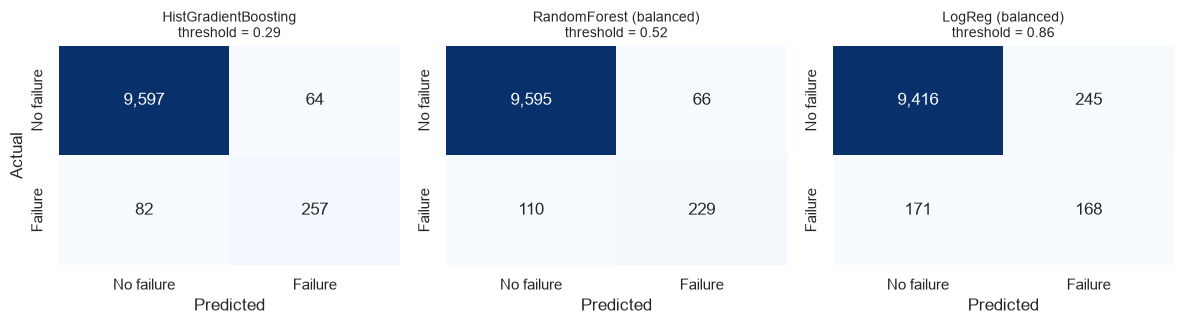

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 3.4))
for ax, name in zip(axes, results.index, strict=True):
    r = results.loc[name]
    cm = pd.DataFrame(
        [[r["tn"], r["fp"]], [r["fn"], r["tp"]]],
        index=["No failure", "Failure"],
        columns=["No failure", "Failure"],
    ).astype(int)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name}\nthreshold = {r['threshold']:.2f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if ax is axes[0] else "")
fig.tight_layout()
save(fig, "confusion_matrices")
plt.show()

## 5. Which failures does the best model miss?

In [6]:
best = results.index[0]
best_threshold = results.loc[best, "threshold"]
caught = probas[best] >= best_threshold

rows = []
for mode, name in FAILURE_MODES.items():
    is_mode = (df[mode] == 1) & (df[TARGET] == 1)
    rows.append(
        {"failure_mode": name, "failures": is_mode.sum(), "caught": (caught & is_mode).sum()}
    )
no_mode = (df[TARGET] == 1) & ~df[list(FAILURE_MODES)].any(axis=1)
rows.append(
    {
        "failure_mode": "No mode flagged",
        "failures": no_mode.sum(),
        "caught": (caught & no_mode).sum(),
    }
)

recall_by_mode = pd.DataFrame(rows).set_index("failure_mode")
recall_by_mode["recall"] = recall_by_mode["caught"] / recall_by_mode["failures"]
recall_by_mode.style.format({"recall": "{:.0%}"})

,failures,caught,recall
failure_mode,,,
Tool wear failure,46,6,13%
Heat dissipation failure,115,108,94%
Power failure,95,79,83%
Overstrain failure,98,88,90%
Random failure,1,0,0%
No mode flagged,9,0,0%


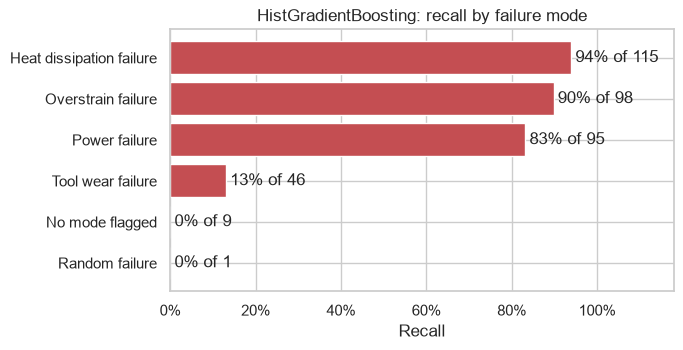

In [7]:
plot_data = recall_by_mode.sort_values("recall")
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.barh(plot_data.index, plot_data["recall"], color=MODEL_COLORS[best])
for i, (r, n) in enumerate(zip(plot_data["recall"], plot_data["failures"], strict=True)):
    ax.text(r + 0.01, i, f"{r:.0%} of {n}", va="center")
ax.set_xlim(0, 1.18)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Recall")
ax.set_title(f"{best}: recall by failure mode")
save(fig, "recall_by_mode")
plt.show()

Failure modes overlap (24 rows have more than one), so the counts add up to more than 339.

- Power, overstrain and heat dissipation failures are caught well, but not perfectly.
- **Tool wear failures** are mostly missed. They happen at a random point between about 200 and
  240 minutes of wear, so the sensors cannot tell *when* a worn tool will fail.
- **Random failures** and failures **without any mode** have no signal at all, as expected.

M4 checks whether the remaining misses among the "physical" failure modes are a limitation of the
data or of the model.

## 6. Reproducing the original notebook

The original notebook reported PR-AUC ≈ 0.86 for gradient boosting. That setup included one
**derived feature**: the temperature difference between process and air
(`process_temp_k - air_temp_k`). Adding it back reproduces the original numbers:

In [8]:
df["temp_diff_k"] = df["process_temp_k"] - df["air_temp_k"]
numeric_ext = NUMERIC_FEATURES + ["temp_diff_k"]
X_ext = df[["type", *numeric_ext]]

results_ext, _ = compare_models(baseline_models(numeric=numeric_ext), X_ext, y, cv=make_cv())

comparison = pd.DataFrame(
    {
        "PR-AUC raw": results["pr_auc"],
        "PR-AUC + temp diff": results_ext["pr_auc"],
        "F1 raw": results["f1"],
        "F1 + temp diff": results_ext["f1"],
    }
)
comparison["PR-AUC gain"] = comparison["PR-AUC + temp diff"] - comparison["PR-AUC raw"]
comparison.loc[results.index].style.format("{:.3f}").format("{:+.3f}", subset=["PR-AUC gain"])

,PR-AUC raw,PR-AUC + temp diff,F1 raw,F1 + temp diff,PR-AUC gain
model,,,,,
HistGradientBoosting,0.835,0.858,0.779,0.804,+0.023
RandomForest (balanced),0.766,0.831,0.722,0.782,+0.065
LogReg (balanced),0.424,0.423,0.447,0.446,-0.000


One simple, physically motivated feature improves gradient boosting by about 0.02 PR-AUC and the
random forest by about 0.06. The trees *can* learn the temperature difference from the two raw
temperatures, but only approximately, with many splits. Giving it to them directly is more efficient.

This is the first hint for the rest of the project: **domain knowledge in the features matters**.
M3 uses explainability to find which other combinations the models are approximating, and M4 builds
them explicitly.

For a clean comparison, the raw-feature models above remain the official baseline.

## 7. Save results

In [9]:
REPORTS_DIR.mkdir(exist_ok=True)
results.to_csv(REPORTS_DIR / "02_baseline_results.csv", float_format="%.4f")

oof = probas.add_prefix("proba_").round(5)
oof.insert(0, TARGET, y)
oof.insert(0, "udi", df["udi"])
oof.to_csv(REPORTS_DIR / "02_baseline_oof.csv", index=False)
print("Saved:", *sorted(p.name for p in REPORTS_DIR.glob("02_*.csv")), sep="\n  ")

Saved:
  02_baseline_oof.csv
  02_baseline_results.csv


## 8. Key takeaways

1. **Best baseline:** histogram gradient boosting on raw features, with PR-AUC ≈ 0.84 and F1 ≈ 0.78
   (about 76% recall at about 80% precision).
2. Linear models fail (PR-AUC ≈ 0.42), because failures depend on non-linear feature interactions.
3. The model misses most **tool wear** failures and, as expected, random failures and failures with
   no mode.
4. Adding a single physics feature (temperature difference) already improves every tree model.
5. The threshold bug from the original notebook is fixed and covered by tests.

**Next (M3):** use SHAP to see *what* the best model has learned and which feature combinations it
approximates.